In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Load your data
df = pd.read_csv('C:/Users/DELL/Downloads/Legal Case/processed_data/legal_cases_complete.csv')

print("=" * 70)
print("LEGAL CORPUS ANALYSIS REPORT")
print("=" * 70)
print(f"\n📊 Dataset Overview:")
print(f"   Total Cases: {len(df):,}")
print(f"   Sources: {df['Source_Folder'].nunique()}")
print(f"   Date Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"   Courts: {df['Court'].nunique()}")
print(f"\n📝 Text Statistics:")
print(f"   Avg Text Length: {df['Case_Text_Full_Length'].mean():.0f} chars")
print(f"   Max Text Length: {df['Case_Text_Full_Length'].max():,} chars")
print(f"   Min Text Length: {df['Case_Text_Full_Length'].min():,} chars")
print(f"\n📚 Citation Statistics:")
print(f"   Total Citations: {df['Num_Citations'].sum():,}")
print(f"   Avg Citations/Case: {df['Num_Citations'].mean():.2f}")
print(f"   Cases with Citations: {(df['Num_Citations'] > 0).sum():,} ({(df['Num_Citations'] > 0).sum()/len(df)*100:.1f}%)")

LEGAL CORPUS ANALYSIS REPORT

📊 Dataset Overview:
   Total Cases: 5,448
   Sources: 21
   Date Range: 1778 - 2019
   Courts: 30

📝 Text Statistics:
   Avg Text Length: 7554 chars
   Max Text Length: 266,325 chars
   Min Text Length: 103 chars

📚 Citation Statistics:
   Total Citations: 42,716
   Avg Citations/Case: 7.84
   Cases with Citations: 5,448 (100.0%)



CASE TYPE DISTRIBUTION
Civil Procedure                      2204 ( 40.5%) ████████████████████
Criminal Law                         1375 ( 25.2%) ████████████
Unclassified                          774 ( 14.2%) ███████
Contract Law - Debt                   478 (  8.8%) ████
Property Law - Ejectment              334 (  6.1%) ███
Torts - Defamation                    172 (  3.2%) █
Torts                                  61 (  1.1%) 
Property Law - Execution Sale          50 (  0.9%) 


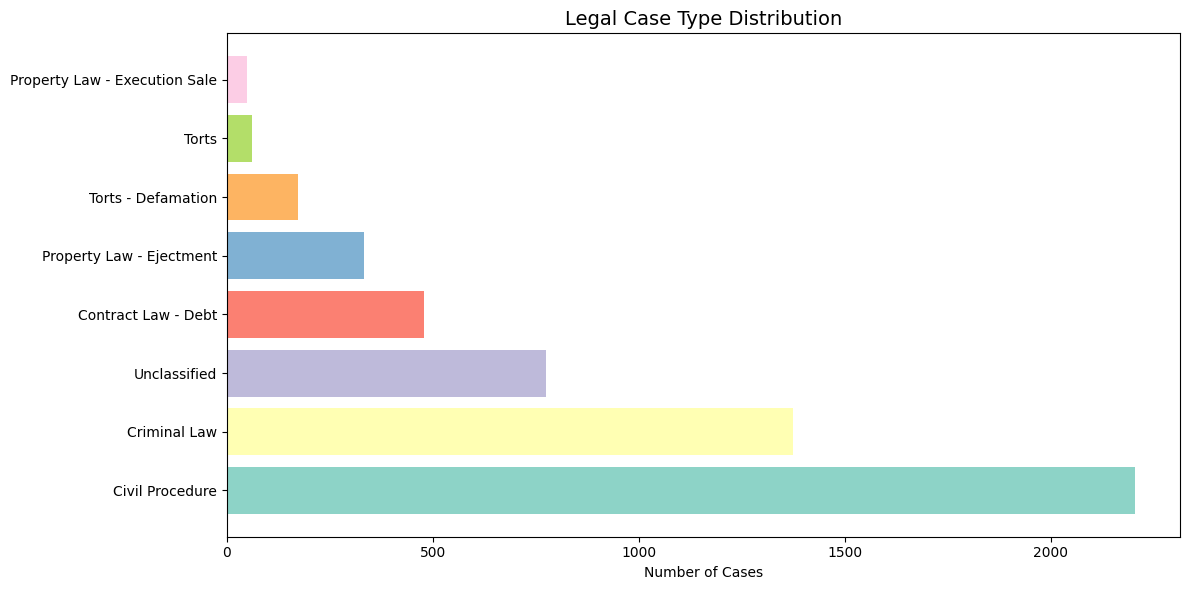

In [2]:
# Case type distribution
print("\n" + "=" * 70)
print("CASE TYPE DISTRIBUTION")
print("=" * 70)

case_type_dist = df['Case_Type'].value_counts()
for ct, count in case_type_dist.items():
    pct = count/len(df)*100
    bar = "█" * int(pct/2)
    print(f"{ct:<35} {count:>5} ({pct:>5.1f}%) {bar}")

# Visualize
plt.figure(figsize=(12, 6))
colors = plt.cm.Set3(range(len(case_type_dist)))
plt.barh(range(len(case_type_dist)), case_type_dist.values, color=colors)
plt.yticks(range(len(case_type_dist)), case_type_dist.index)
plt.xlabel('Number of Cases')
plt.title('Legal Case Type Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('case_type_distribution.png', dpi=150)
plt.show()

In [ ]:
# Verdict distribution
print("\n" + "=" * 70)
print("VERDICT DISTRIBUTION")
print("=" * 70)

verdict_dist = df['Verdict'].value_counts()
for v, count in verdict_dist.head(15).items():
    pct = count/len(df)*100
    print(f"{v:<35} {count:>5} ({pct:>5.1f}%)")

# Known vs Unknown verdicts
known_verdicts = df[df['Verdict'] != 'Verdict Unknown']
unknown_verdicts = df[df['Verdict'] == 'Verdict Unknown']

print(f"\n✅ Known Verdicts: {len(known_verdicts):,} ({len(known_verdicts)/len(df)*100:.1f}%)")
print(f"❌ Unknown Verdicts: {len(unknown_verdicts):,} ({len(unknown_verdicts)/len(df)*100:.1f}%)")

# Outcome analysis for known verdicts
print("\n⚖️ Case Outcomes (Known Verdicts Only):")
outcomes = known_verdicts['Verdict'].str.contains('AFFIRMED|REVERSED|SET ASIDE')
affirmed = known_verdicts['Verdict'].str.contains('AFFIRMED').sum()
reversed_count = known_verdicts['Verdict'].str.contains('REVERSED').sum()
set_aside = known_verdicts['Verdict'].str.contains('SET ASIDE').sum()

print(f"   Affirmed: {affirmed} ({affirmed/len(known_verdicts)*100:.1f}%)")
print(f"   Reversed: {reversed_count} ({reversed_count/len(known_verdicts)*100:.1f}%)")
print(f"   Set Aside: {set_aside} ({set_aside/len(known_verdicts)*100:.1f}%)")